In [1]:

import json
import joblib
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn import set_config
os.chdir(r"C:\Users\angel\Desktop\Proyectos_privados\PROYECTOS\EasyMoney_Capstone")
from src.utils import *
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , roc_auc_score,f1_score,recall_score ,roc_curve,precision_score

from itertools import combinations
from scipy.stats import chi2_contingency
pd.set_option('display.max_columns', None)

set_config(transform_output="pandas")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
target = ["sales_account"]
lista_cod_reg = pd.read_csv("data/raw/codigo_region.csv", sep=";")


## 1. Carga de data procesada , imputada y limpia

In [2]:
dev_df = pd.read_csv("data/processed/output_data_enriquesida_muestra_limpia_develop.csv", sep="|", low_memory=False)
val_df = pd.read_csv("data/processed/output_data_enriquesida_muestra_limpia_validacion.csv",  sep="|", low_memory=False)



## 2. En esta parte se divide la parte de validacion con develop

In [3]:
dev_df_X = dev_df.drop('sales_account', axis=1)
dev_df_y = dev_df[['sales_account']]

val_df_X = val_df.drop('sales_account', axis=1)
val_df_y = val_df[['sales_account']]


## 3. Se genera la divicion de train y test

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(dev_df_X,
                                                    dev_df_y, test_size=0.2, random_state=42)


## 5. se selecciona el modelo

In [5]:
model = LogisticRegression()
model.fit(X_train, Y_train)


c:\Users\angel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\angel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## 6. Se genera las metricas del modelo


TRAIN -> Accuracy: 0.878, Precision: 0.690, Recall: 0.411, F1: 0.516, ROC AUC: 0.874
Matriz de confusión:
[[190374   6803]
 [ 21680  15153]] 

TEST  -> Accuracy: 0.878, Precision: 0.680, Recall: 0.416, F1: 0.516, ROC AUC: 0.877
Matriz de confusión:
[[47547  1791]
 [ 5355  3810]] 

VALID -> Accuracy: 0.890, Precision: 0.567, Recall: 0.560, F1: 0.564, ROC AUC: 0.872
Matriz de confusión:
[[44176  2939]
 [ 3025  3850]] 



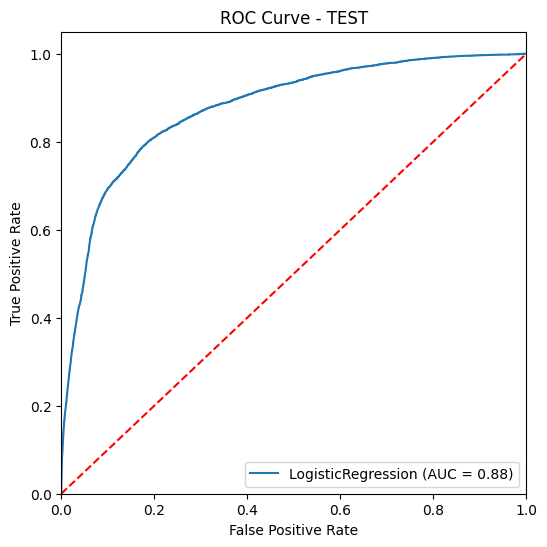

In [6]:
comentario = "modelo Base"
evaluate_model(model, X_train, X_test, val_df_X, Y_train,
               Y_test, val_df_y, comentario, threshold=0.5)


## 7. Resultados Totales

In [7]:
name_model = model.__class__.__name__

df = pd.read_csv("results/metrics/model_metrics.csv",
                 sep=",", low_memory=False)
df[df['Nombre_Modelo'] == name_model]


,Nombre_Modelo,timestamp,PROCESO,METRICA,VALOR,Comentario
0,LogisticRegression,2026-03-15 20:37:08,TRAIN,Accuracy,0.8780,modelo Base
1,LogisticRegression,2026-03-15 20:37:08,TRAIN,Precision,0.6900,modelo Base
2,LogisticRegression,2026-03-15 20:37:08,TRAIN,Recall,0.4110,modelo Base
3,LogisticRegression,2026-03-15 20:37:08,TRAIN,F1,0.5160,modelo Base
4,LogisticRegression,2026-03-15 20:37:08,TRAIN,ROC_AUC,0.8740,modelo Base
5,LogisticRegression,2026-03-15 20:37:08,TEST,Accuracy,0.8780,modelo Base
6,LogisticRegression,2026-03-15 20:37:08,TEST,Precision,0.6800,modelo Base
7,LogisticRegression,2026-03-15 20:37:08,TEST,Recall,0.4160,modelo Base
8,LogisticRegression,2026-03-15 20:37:08,TEST,F1,0.5160,modelo Base
9,LogisticRegression,2026-03-15 20:37:08,TEST,ROC_AUC,0.8770,modelo Base


## 8. Guardar el modelo

In [8]:
import pickle

with open(f"results/model/{name_model}.pkl", "wb") as f:
    pickle.dump(model, f)
